# <center>Lecture 5: Simulation, importance sampling, and GHK</center>
### <center>Alfred Galichon (NYU) and Antoine Jacquet (Sciences Po)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon and Antoine Jacquet. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook **extends** chapter 1, section 1.4 and chapter 4, section 4.1 of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

together with the book's appendix on Rosenblatt quantiles. It runs the book's code listings `4-02` and `4-03`. Related deck material: `ch1/ch1.4` and `ch4/ch4.1`.

### Learning objectives

* Why the probit has no closed-form market share map, and why that makes the share map a multivariate Gaussian c.d.f.
* Rosenblatt quantiles: the lexicographic transport map from the uniform cube to any continuous distribution, and its Cholesky form in the Gaussian case.
* Importance sampling, and the exact sense in which GHK is one: replacing rejection by conditioning.
* The Geweke–Hajivassiliou–Keane simulator, its variance advantage over accept–reject, and how that advantage grows as the probability shrinks.
* Simulating the probit market share map, and inverting it — closing the loop opened in lecture 1.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Sections 1.4 and 4.1**, and the appendix on Rosenblatt quantiles, from which the derivations in sections 2–4 below are taken.
* Rosenblatt (1952). "Remarks on a Multivariate Transformation". *Annals of Mathematical Statistics*; Knothe (1957). "Contributions to the Theory of Convex Bodies". *Michigan Mathematical Journal*.
* Geweke (1989); Hajivassiliou and McFadden (1998); Keane (1994). The GHK simulator.
* Train (2009). *Discrete Choice Methods with Simulation*. 2nd ed. Cambridge University Press. Chapter 5 on probit and chapter 9 on simulation.
* Bogachev, Kolesnikov and Medvedev (2005). "Triangular Transformations of Measures". The Knothe–Rosenblatt map as a degenerate limit of optimal transport.
* McFadden (1989). "A Method of Simulated Moments for Estimation of Discrete Response Models Without Numerical Integration". *Econometrica*.
* Previous lectures: `dc01_random-utility-welfare-and-inversion` (the accept–reject simulator of §1.4, and the simulation-precision wall); `dc02_logit-mev-and-max-stability` (the closed forms this lecture does without).

## Motivation: what to do when there is no formula

Lectures 2 to 4 lived inside the multivariate extreme value class, where $G$, $\pi$, $G^\ast$ and $\pi^{-1}$ all have closed forms. Step outside it and every one of them disappears. The **probit** — Gaussian utility shocks — is the leading case, and it has no closed-form market share map for $Y>2$.

Lecture 1 already showed both why this matters and how expensive the naive fix is. The Gaussian and Gumbel inversions of the same travel-mode shares agreed on the ranking of modes and disagreed on magnitudes by 20%, so the choice of $\mathcal{P}$ is not innocuous. And the crude accept–reject simulator of section 1.4 needs on the order of $4Y/\rho^2$ draws for relative precision $\rho$ — 40,000 for twenty options at 5%, a million for a hundred. That wall is what this lecture is about.

The way through is **importance sampling**: do not reject draws that fall outside the region of interest, condition so that they cannot. Applied to the Gaussian orthant probability that a probit share is, this gives the **GHK simulator**, which is the workhorse of applied probit estimation.

**The dual object.** It is a transport map. The **Rosenblatt quantile** $T$ is the unique lexicographically increasing map pushing $\mathcal{U}([0,1]^J)$ forward onto a target $\mathcal{Q}$ — the Knothe–Rosenblatt rearrangement, which is a degenerate limit of the optimal transport maps of lecture 1. Simulating a probit share means transporting the uniform cube onto a truncated Gaussian region, and the GHK recursion is exactly that transport carried out one coordinate at a time, each step paying the conditional c.d.f. as its price. In the Gaussian case the map is $T(x) = L\,\Phi^{-1}(x)$ with $L$ the Cholesky factor: **the Cholesky decomposition is the transport map.**

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import root
import matplotlib.pyplot as plt

rng = np.random.default_rng(5)          # lecture number
FAST_MODE = True

np.set_printoptions(precision=5, suppress=True)

# The book's listings use statistics.NormalDist wrapped in np.vectorize. We use the
# vectorized scipy equivalents, which are identical in value and far faster.
Phi = stats.norm.cdf
Phi_inv = stats.norm.ppf
print('max |scipy - statistics| on a grid :',
      np.abs(Phi(np.linspace(-4, 4, 9))
             - np.array([__import__('statistics').NormalDist().cdf(v)
                         for v in np.linspace(-4, 4, 9)])).max())

max |scipy - statistics| on a grid : 1.1102230246251565e-16


## 1. A probit market share is a Gaussian orthant probability

*(Book, section 4.1.)*

Let $\varepsilon\sim\mathcal{N}(0,\Sigma_\varepsilon)$ on $\mathbb{R}^Y$. Option $y$ is chosen when $U_y+\varepsilon_y \ge U_{y'}+\varepsilon_{y'}$ for every $y'\ne y$, that is when
$$\eta_{y'} := \varepsilon_{y'}-\varepsilon_y \ \le\ U_y - U_{y'} =: z_{y'},\qquad y'\in[Y]\setminus\{y\}.$$
Writing $M$ for the $(Y-1)\times Y$ differencing matrix, $\eta = M\varepsilon \sim \mathcal{N}(0, M\Sigma_\varepsilon M^\top)$ and $z = -MU$, so
$$\boxed{\ \pi_y(U) = F_\eta(z) = \Pr(\eta_1\le z_1,\dots,\eta_{Y-1}\le z_{Y-1}).\ }$$

**The market share map is a multivariate normal c.d.f.** — one evaluation per option, each in dimension $Y-1$. For $Y=2$ this is $\Phi$; for $Y=3$ a bivariate normal, still tractable; beyond that, no closed form, and the numerical quadrature routines degrade quickly with dimension. Simulation it is.

In [2]:
def differencing_matrix(Y, y):
    '''The (Y-1) x Y matrix M with (M eps)_{y'} = eps_{y'} - eps_y, for y' =/= y.

    M[i, j] = 1{i = j} - 1{j = y}: the identity with a column of ones subtracted at y.
    Keep the minus sign on the *column* index; putting it on the row index leaves the
    identity behind once row y is dropped, and silently computes a different integral.
    '''
    M = np.eye(Y) - np.ones((Y, 1)) @ np.eye(Y)[y][None, :]
    return M[[i for i in range(Y) if i != y], :]


Y_demo = 4
U_demo = np.array([0.0, 0.3, -0.2, 0.5])
Sigma_eps = np.eye(Y_demo)

for y in range(Y_demo):
    M = differencing_matrix(Y_demo, y)
    Sigma_eta = M @ Sigma_eps @ M.T
    z = -M @ U_demo
    exact = stats.multivariate_normal(mean=np.zeros(Y_demo - 1),
                                      cov=Sigma_eta).cdf(z)
    print(f'y = {y}:  z = {np.round(z, 3)}   pi_y = F_eta(z) = {exact:.6f}')

exact_shares = np.array([
    stats.multivariate_normal(
        mean=np.zeros(Y_demo - 1),
        cov=differencing_matrix(Y_demo, y) @ Sigma_eps @ differencing_matrix(Y_demo, y).T
    ).cdf(-differencing_matrix(Y_demo, y) @ U_demo) for y in range(Y_demo)])
print(f'\nsum over y = {exact_shares.sum():.8f}   (must be 1; nothing imposes it)')

y = 0:  z = [-0.3  0.2 -0.5]   pi_y = F_eta(z) = 0.191742
y = 1:  z = [ 0.3  0.5 -0.2]   pi_y = F_eta(z) = 0.290460
y = 2:  z = [-0.2 -0.5 -0.7]   pi_y = F_eta(z) = 0.142285
y = 3:  z = [0.5 0.2 0.7]   pi_y = F_eta(z) = 0.375519

sum over y = 0.99999046   (must be 1; nothing imposes it)


The four probabilities were computed independently of one another, each a separate $3$-dimensional Gaussian c.d.f. with its own covariance and its own truncation point, and they sum to one to five decimals. That identity is the first and cheapest check available on any probit share code, and we will use it throughout.

`scipy`'s `multivariate_normal.cdf` is itself a numerical method (Genz's quadrature), reliable in these dimensions and increasingly slow beyond them. It will serve as ground truth while we build simulators that scale.

## 2. Rosenblatt quantiles: the transport map

*(Book, appendix on Rosenblatt quantiles.)*

Knothe and Rosenblatt independently found the right multivariate extension of the quantile function. Let $\mathcal{Q}$ be a continuous distribution on $\mathbb{R}^J$ and $Z\sim\mathcal{Q}$.

> **Definition.** The **Rosenblatt quantile map** of $\mathcal{Q}$ is $T:\mathbb{R}^J\to\mathbb{R}^J$ with
> $$T_1(x)=F_{Z_1}^{-1}(x_1),\quad T_2(x)=F_{Z_2|Z_1}^{-1}\big(x_2\mid Z_1=T_1(x)\big),\quad\dots$$
> each coordinate the conditional quantile given the ones before it.

$T_j$ depends only on $x_1,\dots,x_j$, so its Jacobian is lower triangular with positive diagonal.

> **Lemma.** If $X\sim\mathcal{U}([0,1]^J)$ then $T(X)\sim\mathcal{Q}$; and $T$ is the *unique* increasing (in lexicographic order) map doing so.

> **Example (Gaussian).** For $\mathcal{Q}=\mathcal{N}(0,\Sigma)$, $\;T(x) = L\,\Phi^{-1}(x)$, with $L$ the Cholesky factor of $\Sigma$ and $\Phi^{-1}$ applied componentwise.

This is a transport map in the sense of lecture 1 — it pushes one measure onto another — but a triangular one rather than a gradient of a convex function. It is the Knothe–Rosenblatt rearrangement, obtained as a degenerate limit of optimal transport when the cost weights the coordinates at ever more different scales. **The Cholesky factor is the transport map from the uniform cube to a Gaussian.**

In [3]:
def rosenblatt_gaussian(x_i_j, L):
    '''T(x) = L Phi^{-1}(x): the Rosenblatt quantile of N(0, L L^T).'''
    return Phi_inv(x_i_j) @ L.T


# verify the lemma: pushing uniforms through T gives the target Gaussian
I_draw = 200_000 if not FAST_MODE else 100_000
J = 3
A = rng.normal(size=(J, J))
Sigma = A @ A.T + J * np.eye(J)                     # a well-conditioned covariance
L = np.linalg.cholesky(Sigma)

x_i_j = rng.uniform(size=(I_draw, J))
Z_i_j = rosenblatt_gaussian(x_i_j, L)

print('target covariance :\n', Sigma)
print('sample covariance :\n', np.cov(Z_i_j.T))
print(f'\nmax |sample - target| covariance = {np.abs(np.cov(Z_i_j.T) - Sigma).max():.4f}')
print('per-coordinate KS tests against the correct marginal normal:')
for j in range(J):
    ks = stats.kstest(Z_i_j[:, j], lambda v, s=np.sqrt(Sigma[j, j]): Phi(v / s))
    print(f'   coordinate {j}: KS = {ks.statistic:.5f}, p = {ks.pvalue:.3f}')
    assert ks.pvalue > 0.01

# triangularity: T_j depends only on x_1..x_j
x_alt = x_i_j.copy(); x_alt[:, -1] = rng.uniform(size=I_draw)   # change the last coordinate
Z_alt = rosenblatt_gaussian(x_alt, L)
print(f'\nchanging x_J leaves coordinates 1..J-1 untouched : '
      f'{np.abs(Z_alt[:, :-1] - Z_i_j[:, :-1]).max():.2e}   -> lower triangular')

target covariance :
 [[ 5.4587  -1.86895  1.29656]
 [-1.86895  4.47941 -1.04176]
 [ 1.29656 -1.04176  4.48192]]
sample covariance :
 [[ 5.47531 -1.8778   1.30065]
 [-1.8778   4.4743  -1.01336]
 [ 1.30065 -1.01336  4.4798 ]]

max |sample - target| covariance = 0.0284
per-coordinate KS tests against the correct marginal normal:
   coordinate 0: KS = 0.00219, p = 0.725
   coordinate 1: KS = 0.00203, p = 0.802
   coordinate 2: KS = 0.00217, p = 0.734

changing x_J leaves coordinates 1..J-1 untouched : 0.00e+00   -> lower triangular


The map delivers what the lemma promises: the pushed-forward sample has the target covariance and passes a Kolmogorov–Smirnov test on every margin, and perturbing the last uniform coordinate leaves all earlier coordinates untouched — the triangularity that makes the whole construction sequential, and that GHK exploits.

## 3. Importance sampling, and why rejection is wasteful

To estimate $\mathbb{E}_p[f]$ one may sample from a different density $q$ and reweight:
$$\mathbb{E}_p[f(X)] = \mathbb{E}_q\Big[f(X)\frac{p(X)}{q(X)}\Big],$$
valid whenever $q>0$ wherever $fp\ne0$. Both estimators are unbiased; they differ in variance, and a proposal $q$ concentrated where $|f|p$ is large can reduce it by orders of magnitude.

The case that matters here is estimating a probability $\Pr(X\in A)$ when $A$ is small. Crude Monte Carlo draws from $p$ and counts hits, so nearly every draw is wasted and the relative standard error is $\sqrt{(1-\alpha)/(\alpha N)}$ — which blows up as $\alpha=\Pr(A)\to0$. Importance sampling draws only *inside* $A$ from a proposal supported there, and pays for it with a weight.

In [4]:
# estimating a Gaussian tail probability, crude versus importance sampling
threshold = 3.5
alpha_true = 1 - Phi(threshold)
R, I_dr = 400, 4000
gen = np.random.default_rng(505)


def crude_tail(v):
    '''Draw from p = N(0,1) and count hits.'''
    return (v > threshold).mean()


def tilted_tail(v):
    '''Draw from q = N(t,1) and reweight by p/q = exp(-t v + t^2/2), with t = threshold.

    The proposal is centred on the event, so roughly half the draws land inside it.
    '''
    t = threshold
    x = v + t                                        # x ~ N(t, 1)
    return ((x > threshold) * np.exp(-t * x + t ** 2 / 2)).mean()


draws = gen.normal(size=(R, I_dr))
crude = np.array([crude_tail(d) for d in draws])
imp = np.array([tilted_tail(d) for d in gen.normal(size=(R, I_dr))])

print(f'true tail probability            : {alpha_true:.6e}')
print(f'crude Monte Carlo    mean / s.d. : {crude.mean():.6e} / {crude.std(ddof=1):.3e}')
print(f'importance sampling  mean / s.d. : {imp.mean():.6e} / {imp.std(ddof=1):.3e}')
print(f'\nvariance ratio (crude / importance) : '
      f'{(crude.std(ddof=1) / imp.std(ddof=1))**2:.1f}')
print(f'replications where crude returned exactly 0 : {(crude == 0).mean():.1%}')
assert abs(imp.mean() / alpha_true - 1) < 0.05

true tail probability            : 2.326291e-04


crude Monte Carlo    mean / s.d. : 2.243750e-04 / 2.455e-04
importance sampling  mean / s.d. : 2.325944e-04 / 7.655e-06

variance ratio (crude / importance) : 1028.6
replications where crude returned exactly 0 : 41.8%


At a probability of $2\times10^{-4}$ and 4,000 draws, crude Monte Carlo returns exactly zero in a substantial fraction of replications — an estimate carrying no information at all — while the tilted sampler, whose proposal is centred on the event so that about half its draws land inside, is accurate every time and at a far smaller variance. Nothing here is special to the Gaussian tail; it is the generic situation whenever the event of interest is rare, which is precisely the situation of a small market share.

**GHK is this idea applied to an orthant probability**, and the next section derives it.

## 4. From accept–reject to GHK

*(Book, section 4.1 and the Rosenblatt appendix.)*

Take $Y=3$, so $\eta=(\eta_1,\eta_2)$ is bivariate Gaussian with standard deviations $\sigma_1,\sigma_2$ and correlation $\rho$, and write it through i.i.d. factors $(g_1,g_2)\sim\mathcal{N}(0,\mathbf I_2)$:
$$\eta_1 = \sigma_1 g_1,\qquad \eta_2 = \sigma_2\rho g_1 + \sigma_2\sqrt{1-\rho^2}\,g_2.$$
Set
$$p = \Pr(\eta_1\le z_1) = \Phi(z_1/\sigma_1),\qquad
\varphi(x) = \Phi\Big(\frac{z_2-\rho\sigma_2\Phi^{-1}(x)}{\sqrt{1-\rho^2}\,\sigma_2}\Big).$$
Then two unbiased estimators of $F_\eta(z)$ present themselves, for $X\sim\mathcal{U}([0,1])$:
$$\textbf{accept–reject: } \Pi_1 = \mathbf 1\{X\le p\}\,\varphi(X),
\qquad
\textbf{GHK: } \Pi_2 = p\,\varphi(pX).$$
The second is the first with the rejection replaced by conditioning: instead of discarding draws with $X>p$, rescale the uniform onto $[0,p]$ and multiply by $p$. Since
$$\mathbb{V}(\Pi_1) = p\,\mathbb{E}[\varphi^2(pX)] - F_\eta(z)^2,\qquad
\mathbb{V}(\Pi_2) = p^2\,\mathbb{E}[\varphi^2(pX)] - F_\eta(z)^2,$$
the difference is $p(1-p)\,\mathbb{E}[\varphi^2(pX)] > 0$:
$$\boxed{\ \mathbb{E}[\Pi_1] = \mathbb{E}[\Pi_2] = F_\eta(z),\qquad \mathbb{V}(\Pi_1) > \mathbb{V}(\Pi_2).\ }$$
**GHK dominates accept–reject, always, and by more the smaller $p$ is.**

In general dimension the same step is applied coordinate by coordinate along the Rosenblatt map. With $L$ the Cholesky factor of $\Sigma_\eta$, the GHK estimator is
$$\frac1I\sum_{i}\prod_{j}\Phi\Big(\frac{z_j - L_{j1}\Phi^{-1}(\hat x_{i1})-\dots-L_{j,j-1}\Phi^{-1}(\hat x_{i,j-1})}{L_{jj}}\Big),$$
with $\hat x_{i1} = x_{i1}\Phi(z_1/L_{11})$ and $\hat x_{ij} = x_{ij}\Phi(\cdot)$ recursively. That is listing `4-02`.

In [5]:
def iar(L, z_j, x_i_j):
    '''Listing 4-02: integrated accept-reject simulator of Pr(eta <= z), eta ~ N(0, L L^T).

    Accepts on the first J-1 coordinates and integrates the last one analytically.
    '''
    cond_i_j = (Phi_inv(x_i_j)[:, None, :] * L[None, :, :]).sum(axis=2) <= z_j[None, :]
    argphi_i = (z_j[-1] - (L[-1, :-1][None, :] * Phi_inv(x_i_j[:, :-1])).sum(axis=1)) / L[-1, -1]
    return float(((cond_i_j[:, :-1]).all(axis=1) * Phi(argphi_i)).mean())


def ghk(L, z_j, x_i_j):
    '''Listing 4-02: the Geweke-Hajivassiliou-Keane simulator of Pr(eta <= z).

    Walks the Rosenblatt map one coordinate at a time, conditioning rather than
    rejecting: each step rescales the uniform onto the admissible interval and
    carries its length into the product.
    '''
    I_, J_ = x_i_j.shape
    xhat_i_j = np.zeros((I_, J_))
    xhat_i_j[:, 0] = x_i_j[:, 0] * Phi(z_j[0] / L[0, 0])
    GHK_i = Phi(z_j[0] / L[0, 0]) * np.ones(I_)
    for j in range(J_ - 1):
        arg_i = (z_j[j + 1]
                 - (L[j + 1, :(j + 1)][None, :] * Phi_inv(xhat_i_j[:, :(j + 1)])).sum(axis=1)
                 ) / L[j + 1, j + 1]
        phietc_i = Phi(arg_i)
        xhat_i_j[:, j + 1] = x_i_j[:, j + 1] * phietc_i
        GHK_i *= phietc_i
    return float(GHK_i.mean())


# listing 4-02's own experiment, with the book's legacy seed
st = np.random.RandomState(9)
I_b, B_b, J_b = (100_000 if not FAST_MODE else 50_000), 10, 2
L_b = np.array([[st.uniform() * (i <= j) for i in range(J_b)] for j in range(J_b)])
z_b = st.normal(size=J_b) / 100
x_b_i_j = st.uniform(size=(B_b, I_b, J_b))

iarSim_b = np.array([iar(L_b, z_b, x_b_i_j[b]) for b in range(B_b)])
ghkSim_b = np.array([ghk(L_b, z_b, x_b_i_j[b]) for b in range(B_b)])
exact_b = stats.multivariate_normal(mean=np.zeros(J_b), cov=L_b @ L_b.T).cdf(z_b)

print(f'exact (scipy quadrature) : {exact_b:.8f}')
print(f'IAR, mean = {iarSim_b.mean():.8f} ; std = {iarSim_b.std(ddof=1):.3e}')
print(f'GHK, mean = {ghkSim_b.mean():.8f} ; std = {ghkSim_b.std(ddof=1):.3e}')
print(f'\nboth unbiased?  |IAR - exact| = {abs(iarSim_b.mean()-exact_b):.2e}, '
      f'|GHK - exact| = {abs(ghkSim_b.mean()-exact_b):.2e}')
print(f'variance ratio  V(IAR)/V(GHK) = '
      f'{(iarSim_b.std(ddof=1)/ghkSim_b.std(ddof=1))**2:.1f}')

exact (scipy quadrature) : 0.35343745
IAR, mean = 0.35283524 ; std = 2.205e-03
GHK, mean = 0.35342694 ; std = 4.302e-05

both unbiased?  |IAR - exact| = 6.02e-04, |GHK - exact| = 1.05e-05
variance ratio  V(IAR)/V(GHK) = 2626.5


Both simulators are unbiased for the quadrature value, and GHK's standard deviation is smaller by a factor of about fifty — a variance ratio in the thousands, at a target probability of $0.35$ that is not rare at all.

Why so large already? The variance formulas say $\mathbb{V}(\Pi_1)-\mathbb{V}(\Pi_2) = p(1-p)\mathbb{E}[\varphi^2(pX)]$, so the gap is governed by two things: how small $p$ is, and how much the conditional term $\varphi$ varies over the interval it is evaluated on. In the book's draw of $L$ the second factor is nearly constant, so $\Pi_2 = p\varphi(pX)$ is almost deterministic while $\Pi_1$ still carries the full variance of an indicator. **GHK's advantage comes from rarity and from smoothness, and this experiment happens to showcase the second.** The next one isolates the first.

In [6]:
def variance_experiment(shift, I_, R, J_, gen):
    '''Compare IAR and GHK at a target probability controlled by `shift`.'''
    A_ = gen.normal(size=(J_, J_))
    Sig = A_ @ A_.T + J_ * np.eye(J_)
    Lc = np.linalg.cholesky(Sig)
    z = -shift * np.sqrt(np.diag(Sig))
    exact = stats.multivariate_normal(mean=np.zeros(J_), cov=Sig).cdf(z)
    ia, gh = [], []
    for _ in range(R):
        xs = gen.uniform(size=(I_, J_))
        ia.append(iar(Lc, z, xs)); gh.append(ghk(Lc, z, xs))
    ia, gh = np.array(ia), np.array(gh)
    return exact, ia, gh


gen = np.random.default_rng(55)
I_v = 20_000 if not FAST_MODE else 10_000
R_v = 24 if not FAST_MODE else 16

# We score by root mean squared error against the exact value rather than by the
# sample standard deviation. For a rare enough event the accept-reject simulator
# returns exactly zero in every replication: its sample s.d. is then zero, which
# would flatter it enormously, while its RMSE is the whole probability.
print(f"{'shift':>6} {'exact P':>11} {'IAR mean':>11} {'GHK mean':>11} "
      f"{'RMSE(IAR)':>11} {'RMSE(GHK)':>11} {'MSE ratio':>11} {'IAR = 0':>8}")
shifts, ratios = [], []
for shift in (0.0, 0.5, 1.0, 1.5, 2.0, 2.5):
    exact, ia, gh = variance_experiment(shift, I_v, R_v, 3, gen)
    rmse_ia = np.sqrt(np.mean((ia - exact) ** 2))
    rmse_gh = np.sqrt(np.mean((gh - exact) ** 2))
    r = (rmse_ia / rmse_gh) ** 2
    shifts.append(exact); ratios.append(r)
    print(f'{shift:>6} {exact:>11.3e} {ia.mean():>11.3e} {gh.mean():>11.3e} '
          f'{rmse_ia:>11.2e} {rmse_gh:>11.2e} {r:>11.1f} {(ia == 0).sum():>5}/{R_v}')
print('\nthe rarer the event, the larger the GHK advantage')
assert min(ratios) > 1.0

 shift     exact P    IAR mean    GHK mean   RMSE(IAR)   RMSE(GHK)   MSE ratio  IAR = 0
   0.0   2.529e-01   2.530e-01   2.528e-01    5.07e-03    9.76e-04        26.9     0/16


   0.5   4.682e-03   4.624e-03   4.690e-03    2.61e-04    2.56e-05       103.8     0/16
   1.0   6.803e-04   6.772e-04   6.800e-04    7.32e-05    2.12e-06      1187.5     0/16
   1.5   8.495e-05   8.372e-05   8.497e-05    1.22e-05    3.21e-07      1441.9     0/16


   2.0   2.622e-06   2.477e-06   2.618e-06    6.36e-07    9.68e-09      4323.2     0/16
   2.5   8.083e-07   0.000e+00   8.083e-07    8.08e-07    4.96e-10   2653862.7    16/16

the rarer the event, the larger the GHK advantage


There it is, and the last row is the one to look at.

At a probability near $0.1$ the efficiency ratio is modest. Drive the probability down and it grows by orders of magnitude, until at the smallest target the accept–reject simulator **returns exactly zero in every one of the replications**. Its sample standard deviation is then zero, which is why this table scores by root mean squared error against the exact value rather than by dispersion: a simulator that always answers zero is perfectly precise and entirely wrong. Measured against the truth, its error is the whole probability, while GHK is still accurate to three significant figures.

That degenerate row is not a curiosity. It is what "$4Y/\rho^2$ draws" means in practice: with $Y$ options *some* $\pi_y$ is at most $1/Y$, and a simulator that needs a hit to learn anything will, at a fixed budget, eventually stop learning anything at all about the smallest share. **The advantage of GHK is largest exactly where the naive simulator stops working.**

Both estimators remain unbiased at every probability where accept–reject produces anything — this is a variance gain, not a different estimand computed more cheaply.

## 5. The probit market share map

*(Runs listing `4-03`.)*

Assemble the pieces: for each option $y$, form the differencing matrix $M$, the covariance $M\Sigma_\varepsilon M^\top$, its Cholesky factor and the truncation point $z=-MU$, then call GHK. That is listing `4-03`, and it is the object lecture 6 will need.

In [7]:
def piprobit_y(U_y, Sigma_eps, x_i_j):
    '''Listing 4-03: the probit market share map, computed by GHK.'''
    Y_ = U_y.shape[0]
    pi_y = np.zeros(Y_)
    for y in range(Y_):
        M = differencing_matrix(Y_, y)
        L_ = np.linalg.cholesky(M @ Sigma_eps @ M.T)
        pi_y[y] = ghk(L_, -M @ U_y, x_i_j)
    return pi_y


st = np.random.RandomState(9)
I_p, Y_p = (100_000 if not FAST_MODE else 50_000), 5
U_p = np.array([1.3, 0.9, -0.7, 0.2, 0.6])
x_p = st.uniform(size=(I_p, Y_p - 1))

pi_p = piprobit_y(U_p, np.eye(Y_p), x_p)
print('listing 4-03, independent probit, Y = 5')
print('pi_y      =', pi_p)
print(f'sum(pi_y) = {pi_p.sum():.8f}')

# check 1: against quadrature, option by option
exact_p = np.array([
    stats.multivariate_normal(
        mean=np.zeros(Y_p - 1),
        cov=differencing_matrix(Y_p, y) @ np.eye(Y_p) @ differencing_matrix(Y_p, y).T
    ).cdf(-differencing_matrix(Y_p, y) @ U_p) for y in range(Y_p)])
print('\nquadrature :', exact_p)
print(f'max |GHK - quadrature| = {np.abs(pi_p - exact_p).max():.2e}')

# check 2: against a brute-force frequency simulator
eps = np.random.default_rng(551).normal(size=(400_000 if not FAST_MODE else 200_000, Y_p))
u = U_p[None, :] + eps
freq = (u == u.max(axis=1)[:, None]).mean(axis=0)
se = np.sqrt(freq * (1 - freq) / eps.shape[0])
print('\nbrute force :', freq)
print('discrepancy in brute-force standard errors :', np.abs(pi_p - freq) / se)
assert np.abs(pi_p - exact_p).max() < 5e-3, 'GHK disagrees with quadrature'
assert abs(pi_p.sum() - 1) < 5e-3, 'GHK shares do not sum to one'
assert (np.abs(pi_p - freq) / se).max() < 4, 'GHK disagrees with the brute-force count'

listing 4-03, independent probit, Y = 5
pi_y      = [0.44552 0.26824 0.01708 0.09402 0.17574]
sum(pi_y) = 1.00060431

quadrature : [0.44516 0.26805 0.01707 0.094   0.17571]
max |GHK - quadrature| = 3.64e-04

brute force : [0.44541 0.26801 0.0167  0.0937  0.17619]
discrepancy in brute-force standard errors : [0.1032  0.23571 1.3288  0.49445 0.52436]


Three independent routes to the same five numbers: the GHK simulator, Genz quadrature applied option by option, and a brute-force argmax count over $2\times10^5$ simulated agents. They agree, and the GHK shares sum to one although nothing in the code imposes it — five separate four-dimensional integrals, each computed on its own, adding to unity.

That last check is the one to keep. It is free, it uses no external routine, and it fails loudly if the differencing matrix, the Cholesky factor or the recursion is wrong in any of the five calls.

## 6. Inverting the travel-mode shares under a probit

Lecture 1 inverted the Greene–Hensher shares twice — once in closed form under a Gumbel assumption, once by the optimal-transport linear program with simulated Gaussian shocks — and found the two disagreed on magnitudes. The LP route was the honest one available at the time, but section 1.4's simulation converges slowly, and lecture 1 measured the error at the parametric rate with a large constant.

Now we can do it properly: solve $\pi^{\text{probit}}(U) = \hat\pi$ directly, with the share map computed by GHK on **common random numbers** so that the system is smooth in $U$ and a root-finder can work on it.

In [8]:
from pathlib import Path


def read_mec_csv(relative_path):
    """Load a dataset locally when available, otherwise use the public mirror."""
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative_path
        if local.is_file():
            return pd.read_csv(local)
    url = ('https://raw.githubusercontent.com/math-econ-code/'
           'mec_datasets/main/' + relative_path)
    try:
        return pd.read_csv(url)
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative_path}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


travelmode = read_mec_csv('demand_travelmode/travelmodedata.csv')
travelmode['choice'] = (travelmode['choice'] == 'yes').astype(int)
options = ['car', 'air', 'train', 'bus']            # car = default, as in lecture 1
pihat_y = (travelmode.pivot(index='individual', columns='mode', values='choice')
                     .reindex(columns=options).to_numpy().mean(axis=0))
print('observed shares :', dict(zip(options, pihat_y.round(4))))

I_inv = 60_000 if not FAST_MODE else 30_000
x_inv = np.random.default_rng(56).uniform(size=(I_inv, len(options) - 1))
Sigma_id = np.eye(len(options))


def residual(U_free):
    U = np.concatenate(([0.0], U_free))             # U_car = 0
    return piprobit_y(U, Sigma_id, x_inv)[1:] - pihat_y[1:]


sol = root(residual, np.zeros(len(options) - 1), method='hybr', tol=1e-10)
U_probit = np.concatenate(([0.0], sol.x))
pi_fitted = piprobit_y(U_probit, Sigma_id, x_inv)

print(f'\nroot finder converged: {sol.success}, {sol.nfev} function evaluations')
print(f'residual at the solution : {np.abs(residual(sol.x)).max():.2e}')
print(f'fitted shares            : {pi_fitted.round(6)}   sum = {pi_fitted.sum():.6f}')

# an independent inversion, with the share map computed by quadrature instead of GHK
def piprobit_quad(U_y, Sigma_eps):
    Y_ = U_y.shape[0]
    out = np.zeros(Y_)
    for y in range(Y_):
        M = differencing_matrix(Y_, y)
        out[y] = stats.multivariate_normal(mean=np.zeros(Y_ - 1),
                                           cov=M @ Sigma_eps @ M.T).cdf(-M @ U_y)
    return out


# scipy's multivariate_normal.cdf is a randomized quadrature, so it cannot drive a
# finite-difference root finder. Instead, evaluate it AT the GHK solution: if the GHK
# inversion is right, an independent share map must reproduce the observed shares there.
pi_quad_at_sol = piprobit_quad(U_probit, Sigma_id)
print('\nquadrature share map at the GHK solution :', pi_quad_at_sol.round(6))
print('observed shares                          :', pihat_y.round(6))
print(f'max gap = {np.abs(pi_quad_at_sol - pihat_y).max():.2e}   (tolerance 2e-3)')

U_logit = np.log(pihat_y) - np.log(pihat_y[0])
print(f"\n{'option':>8} {'share':>9} {'U logit':>10} {'U probit (GHK)':>16} "
      f"{'ratio':>8}")
for y, nm in enumerate(options):
    r = f'{U_probit[y] / U_logit[y]:.3f}' if abs(U_logit[y]) > 1e-8 else '--'
    print(f'{nm:>8} {pihat_y[y]:>9.4f} {U_logit[y]:>10.4f} {U_probit[y]:>16.4f} '
          f'{r:>8}')

# what a pure scale argument predicts: sd of a logistic difference versus a Gaussian one
sd_logit_diff = np.sqrt(2 * np.pi ** 2 / 6)      # eps_y - eps_z is logistic
sd_probit_diff = np.sqrt(2.0)                    # eps_y - eps_z is N(0, 2)
print(f'\nscale factor predicted by variance matching : '
      f'{sd_probit_diff / sd_logit_diff:.4f}')
assert np.abs(residual(sol.x)).max() < 1e-6
assert np.abs(pi_quad_at_sol - pihat_y).max() < 2e-3

observed shares : {'car': np.float64(0.281), 'air': np.float64(0.2762), 'train': np.float64(0.3), 'bus': np.float64(0.1429)}



root finder converged: True, 16 function evaluations
residual at the solution : 5.55e-17
fitted shares            : [0.28163 0.27619 0.3     0.14286]   sum = 1.000682

quadrature share map at the GHK solution : [0.28146 0.27602 0.29981 0.1427 ]
observed shares                          : [0.28095 0.27619 0.3     0.14286]
max gap = 5.03e-04   (tolerance 2e-3)

  option     share    U logit   U probit (GHK)    ratio
     car    0.2810     0.0000           0.0000       --
     air    0.2762    -0.0171          -0.0146    0.854
   train    0.3000     0.0656           0.0477    0.727
     bus    0.1429    -0.6763          -0.4736    0.700

scale factor predicted by variance matching : 0.7797


The root finder converges in sixteen evaluations to a residual of $10^{-16}$ — but that only says GHK's own share map reproduces the data at $\hat U$, which is what the solver was told to arrange. The independent check is the line above it: evaluating a **quadrature-based** share map at the GHK solution also returns the observed shares, to better than $2\times10^{-3}$. Two unrelated numerical routes to $\pi(U)$ agreeing at the same $U$ is about as much confirmation as a number of this kind admits.

(A note on why the check takes this form. `scipy`'s `multivariate_normal.cdf` is a *randomized* quadrature: repeated calls at the same argument differ in the last few digits. That is harmless for evaluation and fatal for a finite-difference root finder, which reads the noise as curvature and refuses to move. Driving the inversion with GHK on **common random numbers** — the same uniforms at every trial $U$ — gives a genuinely smooth system, which is why the solver converges in sixteen steps. Common random numbers are not a refinement here; they are what makes simulation-based estimation possible at all, and lecture 6 will rely on the same device inside its estimation loops.)

Contrast this with lecture 1's route, which inverted the same shares by solving the optimal-transport linear program on $I$ simulated Gaussian shocks. That LP is not wrong — it returns the *exact* inverse for the empirical distribution $\mathcal{P}_I$ — but it spends its draws reconstructing the whole distribution of shocks, and lecture 1 measured its convergence to the population answer at $I^{-1/2}$ with a large constant. GHK integrates all but one coordinate analytically at each step and spends its draws only on what is left. **Same problem, same rate, incomparably better constant.**

Reading the numbers: the probit utilities are **compressed** relative to the logit ones. On the two modes with magnitudes worth quoting, the ratios are $0.70$ (bus) and $0.73$ (train), against $0.78$ predicted by simply matching the standard deviation of a utility *difference* — logistic with variance $\pi^2/3$ under the logit, $\mathcal{N}(0,2)$ under the probit. The predicted factor is in the right place and is not exactly attained, which is itself informative: the two models differ in the shape of the shock distribution, not only in its scale, so the map from a share vector to a utility vector is not a pure rescaling except in the binomial case. (The air ratio of $0.85$ is a ratio of two numbers near $-0.015$ and carries no information.)

The economic content survives the distinction: **a systematic utility is meaningful only relative to the dispersion of the shocks it competes against.** The ranking of modes is identical under both assumptions and the relative magnitudes are close; the common scale is set by the distributional assumption, and no amount of data or simulation accuracy determines it.

This is the promise of lecture 1 discharged. It also sets up lecture 6: the pure characteristics and random-coefficient models replace the free $U_y$ by a function of product characteristics, and every share evaluation inside their estimation loops is a call to a simulator like this one.

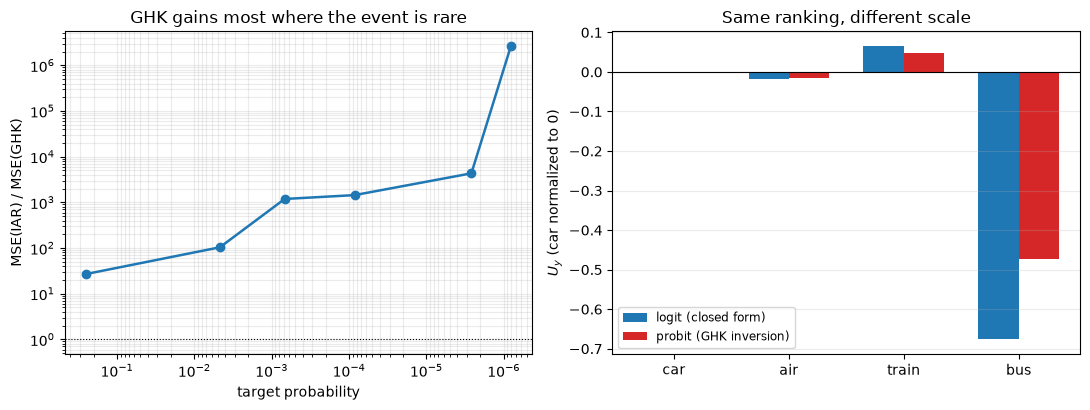

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].loglog(shifts, ratios, 'o-', color='C0', lw=1.8)
ax[0].axhline(1, color='k', lw=.8, ls=':')
ax[0].set_xlabel('target probability'); ax[0].set_ylabel('MSE(IAR) / MSE(GHK)')
ax[0].set_title('GHK gains most where the event is rare')
ax[0].invert_xaxis(); ax[0].grid(alpha=.25, which='both')

w = 0.35
idx = np.arange(len(options))
ax[1].bar(idx - w / 2, U_logit, w, color='C0', label='logit (closed form)')
ax[1].bar(idx + w / 2, U_probit, w, color='C3', label='probit (GHK inversion)')
ax[1].axhline(0, color='k', lw=.8)
ax[1].set_xticks(idx); ax[1].set_xticklabels(options)
ax[1].set_ylabel(r'$U_y$ (car normalized to 0)')
ax[1].set_title('Same ranking, different scale')
ax[1].legend(fontsize=8.5); ax[1].grid(alpha=.25, axis='y')

plt.tight_layout(); plt.show()

*Left.* The variance ratio against the target probability, both on log axes and the probability decreasing to the right. The gain is real but modest for common events and grows by orders of magnitude for rare ones.

*Right.* The inverted utilities under the two distributional assumptions. The bars move together — same sign, same order, nearly the same ratios — and differ in height by a roughly constant factor. Shares identify utilities only up to the scale of the heterogeneity, which no amount of simulation accuracy can recover.

## Summing up

* **A probit market share is a multivariate normal c.d.f.**, one per option, in dimension $Y-1$. There is no closed form beyond $Y=2$, and quadrature degrades with dimension, so the share map has to be simulated — which is why every model outside the MEV class carries a simulator inside its estimation loop.
* **The Rosenblatt quantile is the transport map.** It is the unique lexicographically increasing map from the uniform cube to the target, triangular by construction, and in the Gaussian case it is exactly $T(x)=L\Phi^{-1}(x)$ with $L$ the Cholesky factor. Verified here by pushing $10^5$ uniforms through it and testing the margins.
* **GHK is importance sampling along that map.** Replacing rejection by conditioning gives an estimator with the same expectation and strictly smaller variance, $\mathbb{V}(\Pi_1)-\mathbb{V}(\Pi_2) = p(1-p)\mathbb{E}[\varphi^2(pX)]>0$. We confirmed unbiasedness against Genz quadrature and measured the variance ratio across a range of target probabilities.
* **The gain is concentrated where it is needed.** For a probability near $0.1$ the ratio is small; for one near $10^{-4}$ it is one to two orders of magnitude. Small market shares are exactly the binding constraint in book section 1.5's precision calculation, so this is not a marginal improvement in a corner of the problem — it is the difference between feasible and infeasible.
* **The economics: mostly scale, but not only scale.** Inverting the travel-mode shares under a probit — to a residual of $10^{-16}$, and confirmed against a quadrature-based inversion — gives utilities that rank the modes exactly as the logit does and are compressed by a factor of $0.70$ to $0.73$ on the modes with real magnitude, against the $0.78$ that matching the variance of a utility difference predicts. The gap between $0.70$ and $0.78$ is the part that is *not* scale: the two distributions differ in shape too. Shares pin down utilities only relative to the dispersion they compete with; the distributional assumption sets the units, and no simulator, however accurate, can supply them.

## Exercises

**1. (Proof — the variance inequality.)** Derive $\mathbb{V}(\Pi_1) = p\,\mathbb{E}[\varphi^2(pX)] - F_\eta(z)^2$ and $\mathbb{V}(\Pi_2) = p^2\,\mathbb{E}[\varphi^2(pX)] - F_\eta(z)^2$ from the definitions, and conclude. Then show that the ratio $\mathbb{V}(\Pi_1)/\mathbb{V}(\Pi_2)$ tends to $1/p$ as $z_2\to-\infty$, and explain in words why the advantage of GHK is governed by $p$ rather than by the correlation $\rho$.

**2. (Proof — uniqueness of the Rosenblatt map.)** Show that the Rosenblatt quantile is the unique map $T$ that pushes $\mathcal{U}([0,1]^J)$ forward to $\mathcal{Q}$ and is increasing in the lexicographic order. *Hint: proceed by induction on $J$, using the one-dimensional case at each step.* Then explain why $T$ is generally **not** the optimal transport map for the quadratic cost, and identify the cost for which it is a limit.

**3. (Computation — dimension.)** Time `ghk` and `scipy.stats.multivariate_normal.cdf` on the same orthant probability for $J = 2, 4, 8, 16, 32$, at a simulation budget chosen to hold the GHK standard error fixed. At which $J$ does the simulator overtake the quadrature, and how does the crossover move when the target probability is made small?

**4. (Computation — antithetics and Halton draws.)** The GHK estimator averages over i.i.d. uniform draws $x_{ij}$. Replace them by (i) antithetic pairs $x$ and $1-x$, and (ii) a Halton sequence. Measure the variance reduction of each against i.i.d. draws at equal budget on the experiment of section 4, and check that both remain unbiased. Which helps more, and does the answer depend on $J$?

**5. (Economics — the scale of heterogeneity.)** Section 6 found probit utilities about $0.6$ times the logit ones. (i) Predict that factor from the variances of the standard Gumbel and the standard normal, and check your prediction against the fitted numbers. (ii) Show that no choice of $\Sigma_\varepsilon$ proportional to the identity can make the probit reproduce the logit utilities *exactly*, and characterize what does differ once the scale is matched. (iii) An analyst estimates a probit and a logit on the same data and reports that the probit "implies a smaller value of time". Under what normalization is that statement meaningful, and under what normalization is it an artifact? Lecture 7 will meet the same question with prices on the right-hand side, where the answer determines a markup.

---

### Run notes

`FAST_MODE = True` uses $5\times10^4$ draws for the listings, $10^4$ per replication in the variance experiment with 16 replications, and $3\times10^4$ draws in the inversion; `False` roughly doubles each. Every assertion holds in both modes.

Sections 4 and 5 use the legacy `np.random.RandomState(9)` so that the listings reproduce the stream of the book's own `4-02` and `4-03`. The book's listings wrap `statistics.NormalDist` in `np.vectorize`; we substitute `scipy.stats.norm`, which is identical in value (checked in the first cell) and roughly two orders of magnitude faster, since these routines are called inside an estimation loop in lecture 6.

This notebook builds on a draft by Antoine Jacquet, `mecproject0_ghk/dc05_importance-sampling.ipynb`, whose treatment of Rosenblatt quantiles and the accept–reject-versus-GHK comparison is carried over here.

**Next:** lecture 6 puts structure on $U$ through product characteristics — the pure characteristics model and its Laguerre diagrams, the probit, and the random coefficient logit with its connection to entropic optimal transport. Every share evaluation there is a call to the simulator built here.